<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- David Santiago Castiblanco

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [1]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [7]:
df_indicators = pd.read_csv("Indicators.csv")

In [8]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [9]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [14]:
df_countries = pd.read_csv("Country.csv")

In [15]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [16]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [17]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [18]:
df_indicators["IndicatorCode"] = df_indicators["IndicatorCode"].replace(nombre_indicadores)
df_indicators.head()

,CountryCode,IndicatorCode,Year,Value
0,CHL,Agricultura (% del PIB),2014,6.75
1,CHL,Comercio (% del PIB),2014,74.31
2,CHL,Crecimiento del PIB (%),2014,7.65
3,CHL,Inflación (%),2014,12.62
4,CHL,Deuda del gob. central (% del PIB),2014,42.83


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [20]:
df_pivot = df_indicators.pivot_table(
    index="CountryCode",
    columns="IndicatorCode",
    values="Value").reset_index()
df_pivot.head()

IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [21]:
df_final = pd.merge(df_pivot, df_countries, on="CountryCode", how="left")
df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [22]:
df_final = df_final.drop(columns=["Region", "CountryCode"])
df_final = df_final.set_index("ShortName")
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [23]:
df_final.isnull().sum()

,0
Agricultura (% del PIB),4
Comercio (% del PIB),3
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),4
Días para cumplir contratos,2
Exportaciones (US$),3
Facilidad para hacer negocios,5
Gasto en educación (% del PIB),3
Gasto en salud (% del PIB),4
Importaciones (US$),3


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [26]:

latam_countries_names = df_countries[df_countries['Region'] == 'Latin America & Caribbean']['ShortName'].tolist()
df_latam = df_final[df_final.index.isin(latam_countries_names)]
df_final_imputed = df_final.copy()
for col in df_final_imputed.columns:
    if df_final_imputed[col].dtype != "object":
        media_latam = df_latam[col].mean()
        df_final_imputed[col] = df_final_imputed[col].fillna(media_latam)

df_final_imputed.isnull().sum()

,0
Agricultura (% del PIB),0
Comercio (% del PIB),0
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),0
Días para cumplir contratos,0
Exportaciones (US$),0
Facilidad para hacer negocios,0
Gasto en educación (% del PIB),0
Gasto en salud (% del PIB),0
Importaciones (US$),0


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

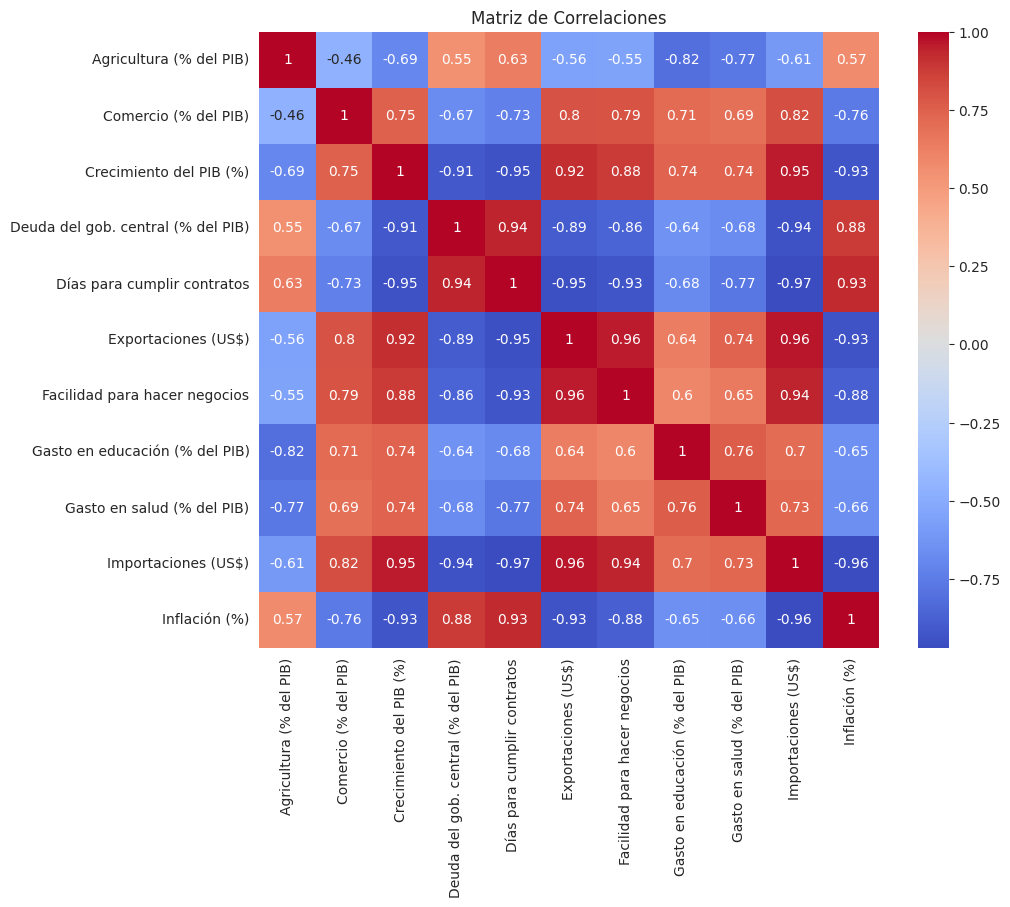

In [28]:
corr = df_final_imputed.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlaciones")
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

3.1
Se calcularon los valores faltantes en cada columna del dataframe utilizando la función correspondiente, lo que permitió identificar en qué variables existían datos incompletos.

3.2
Se realizó una imputación de los valores faltantes utilizando el promedio de los países de Latinoamérica para cada variable. Primero se filtraron los países pertenecientes a la región de Latinoamérica y el Caribe, luego se calculó la media de cada columna numérica y se reemplazaron los valores faltantes por dicho promedio. Finalmente, se verificó que no quedaran valores faltantes en el dataframe resultante.

4.1
Se construyó una matriz de correlaciones entre las variables numéricas del dataframe imputado. Posteriormente, se graficó un mapa de calor que permite visualizar la intensidad y dirección de las relaciones entre las variables.

4.2
Se observa que las variables relacionadas con comercio, como exportaciones e importaciones, presentan una alta correlación positiva, lo cual es consistente con economías abiertas. Asimismo, el crecimiento del PIB muestra relaciones positivas con variables económicas clave, mientras que la inflación tiende a presentar una relación negativa con el crecimiento. Por otro lado, variables fiscales como el gasto público y la deuda presentan correlaciones moderadas entre sí.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final_imputed)
print(X_scaled)

[[ 1.56751909e+00 -2.32214925e+00 -1.55490929e+00  1.41734406e+00
   1.65462324e+00 -1.67830091e+00 -1.45497675e+00 -2.80876841e+00
  -2.17343045e+00 -1.67603381e+00  1.66608784e+00]
 [-9.69817622e-16 -1.65234419e-01 -7.04531874e-01  7.85802281e-01
   9.42751202e-01 -8.07009683e-01  3.65012495e-16  2.00383429e-01
  -1.20640046e+00 -7.32586119e-01  1.03366672e+00]
 [ 2.14398279e+00  4.03097795e-01 -3.86677474e-01 -1.53937027e-01
   3.95565696e-01 -2.22965190e-02 -3.21553933e-01 -6.16134769e-01
  -9.44212581e-01 -8.18476741e-02  2.31596854e-01]
 [-1.15394252e+00  1.79017362e+00  1.56397425e+00 -1.57585379e+00
  -1.57008213e+00  1.56950572e+00  1.57883382e+00  1.22258235e+00
   2.05907528e+00  1.43962595e+00 -7.65797604e-01]
 [-1.05714110e+00  3.81256614e-01  1.16013963e+00 -1.06920346e+00
  -6.34094075e-01  3.52027394e-16  3.65012495e-16  1.17923427e+00
   5.64114361e-02  7.85739949e-01 -8.42886139e-01]
 [-4.10003438e-01  1.45125097e+00  8.84519851e-01  7.03276486e-16
  -8.59426986e-01  

### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [31]:
from sklearn.decomposition import PCA
import numpy as np
pca = PCA()
pca.fit(X_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(varianza_acumulada)

[0.80432386 0.89486154 0.93597174 0.95991133 0.97641891 0.9864744
 0.99249496 0.99665217 0.99895635 0.99961687 1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

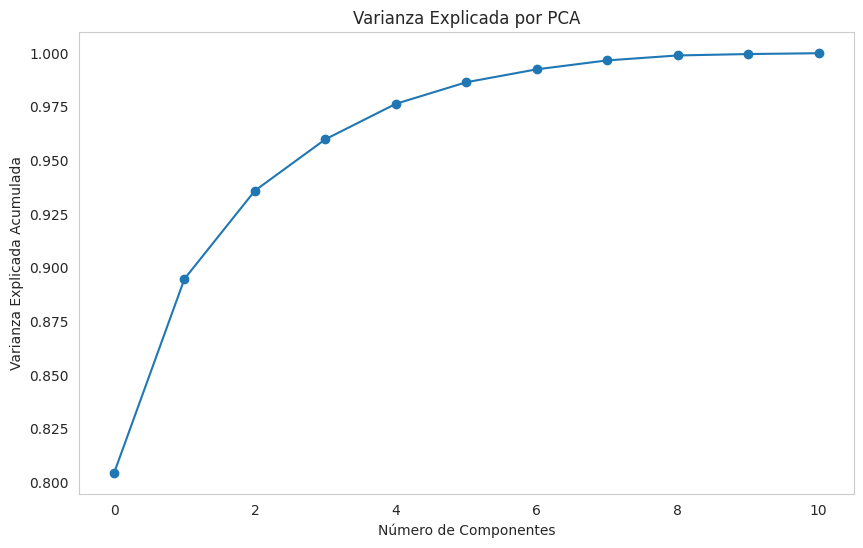

In [33]:
plt.plot(varianza_acumulada, marker='o')
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Varianza Explicada por PCA")
plt.grid()
plt.show()

5.3. Realiza un análisis del gráfico anterior.

La varianza acumulada aumenta a medida que se incrementa el número de componentes. Se observa que con pocos componentes se logra explicar una gran proporción de la varianza total, lo que indica que es posible reducir la dimensionalidad sin perder demasiada información. El punto donde la curva comienza a estabilizarse sugiere el número óptimo de componentes a utilizar.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [35]:
from sklearn.decomposition import PCA
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)
print(X_pca)

[[-5.93163943]
 [-1.93288957]
 [-1.24450158]
 [ 4.89445994]
 [ 2.13036856]
 [ 2.74868463]
 [-0.21121406]
 [-1.79290845]
 [ 0.97435042]
 [ 3.8873418 ]
 [ 0.66447112]
 [ 1.08646188]
 [-0.1361746 ]
 [-5.13681067]]


6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

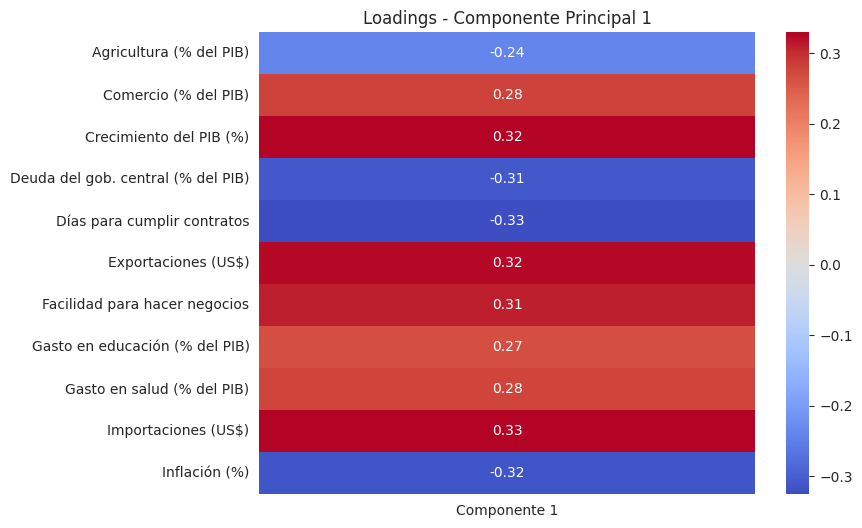

In [36]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=df_final_imputed.columns,
    columns=["Componente 1"])
plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("Loadings - Componente Principal 1")
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

- El primer componente principal recoge la mayor parte de la varianza del sistema, por lo que resume la información de las variables originales. Las variables con cargas altas y positivas son aquellas que contribuyen directamente al aumento del componente, como el comercio, las exportaciones y el crecimiento económico. Por otro lado, las variables con cargas negativas, como la inflación o niveles altos de deuda, afectan de manera inversa al componente.

Esto sugiere que el componente 1 puede interpretarse como un indicador general del desempeño económico o del clima de inversión. Un valor alto del componente estaría asociado a economías con mayor crecimiento, apertura comercial y estabilidad, mientras que valores bajos reflejarían economías con mayores desequilibrios macroeconómicos.

### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [ ]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [40]:
# Crear dataframe para ranking desde el dataframe imputado
df_ranking = df_final_imputed.copy()

# Agregar el índice de inversión
df_ranking["Indice_Inversion"] = X_pca[:, 0]

# Ordenar de mayor a menor
df_ranking = df_ranking.sort_values(by="Indice_Inversion", ascending=False)

df_ranking.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
Panamá,5.80,56.08,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89
Costa Rica,8.11,70.86,5.88,58.75,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
Colombia,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61,2.13
Uruguay,8.21,64.01,4.47,58.75,717.08,"63,598,148,937.21",3.96,5.63,6.65,"59,086,857,093.80",11.66,1.09


7.2. Convierte 'ShortName' en una columna del dataframe.

In [41]:
df_ranking = df_ranking.reset_index()
df_ranking.head()

,ShortName,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
0,Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
1,Panamá,5.80,56.08,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89
2,Costa Rica,8.11,70.86,5.88,58.75,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
3,Colombia,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61,2.13
4,Uruguay,8.21,64.01,4.47,58.75,717.08,"63,598,148,937.21",3.96,5.63,6.65,"59,086,857,093.80",11.66,1.09


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

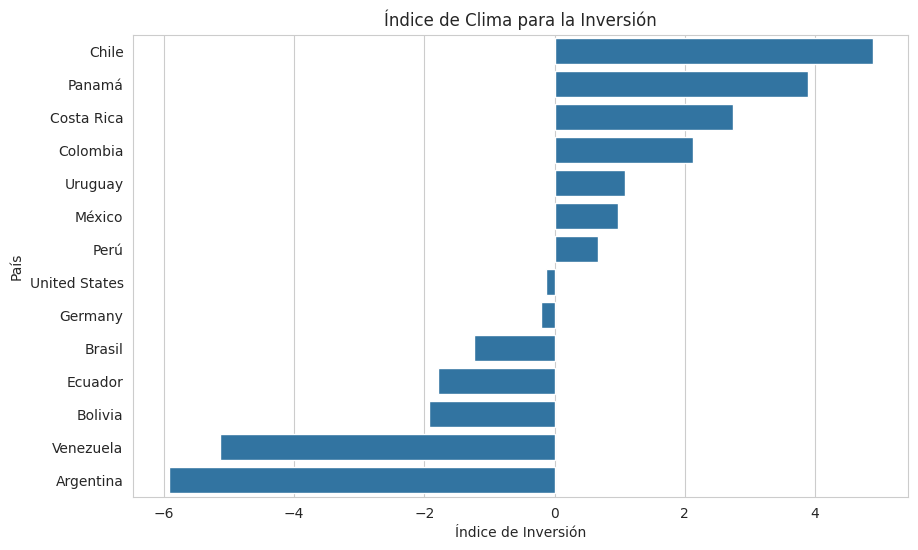

In [42]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_ranking,
    y="ShortName",
    x="Indice_Inversion")
plt.title("Índice de Clima para la Inversión")
plt.xlabel("Índice de Inversión")
plt.ylabel("País")
plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

-El ranking del índice de clima para la inversión muestra diferencias claras entre los países de la región. Aquellos con valores más altos presentan mejores condiciones económicas, mayor estabilidad y mayor apertura comercial, lo que los hace más atractivos para la inversión extranjera.